## <b> DATA ANALYSIS <b>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

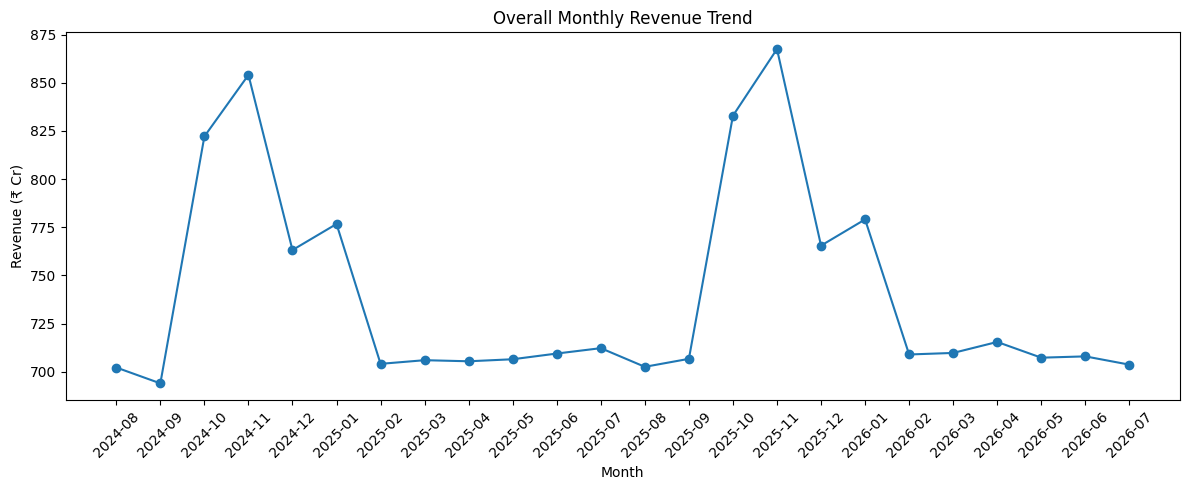

In [2]:
orders = pd.read_csv("orders.csv")
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['revenue'] = orders['qty_delivered'] * orders['unit_price']
orders['month'] = orders['order_date'].dt.to_period('M')

monthly = orders.groupby('month')['revenue'].sum() / 1e7

plt.figure(figsize=(12,5))
plt.plot(monthly.index.astype(str), monthly.values, marker='o')
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue (₹ Cr)")
plt.title("Overall Monthly Revenue Trend")
plt.tight_layout()
plt.show()

In [3]:
print(monthly.round(2))

month
2024-08    702.19
2024-09    693.97
2024-10    822.15
2024-11    854.07
2024-12    763.18
2025-01    776.70
2025-02    704.10
2025-03    706.00
2025-04    705.43
2025-05    706.49
2025-06    709.45
2025-07    712.24
2025-08    702.56
2025-09    706.70
2025-10    832.89
2025-11    867.51
2025-12    765.47
2026-01    779.07
2026-02    708.96
2026-03    709.76
2026-04    715.46
2026-05    707.30
2026-06    707.98
2026-07    703.68
Freq: M, Name: revenue, dtype: float64


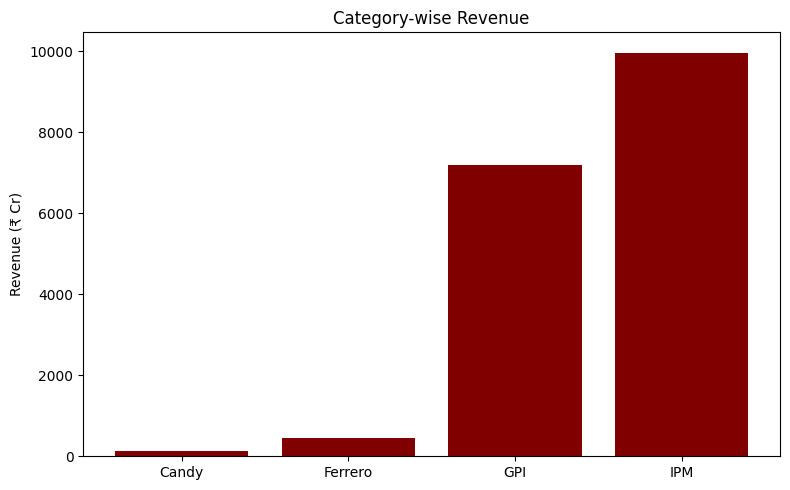

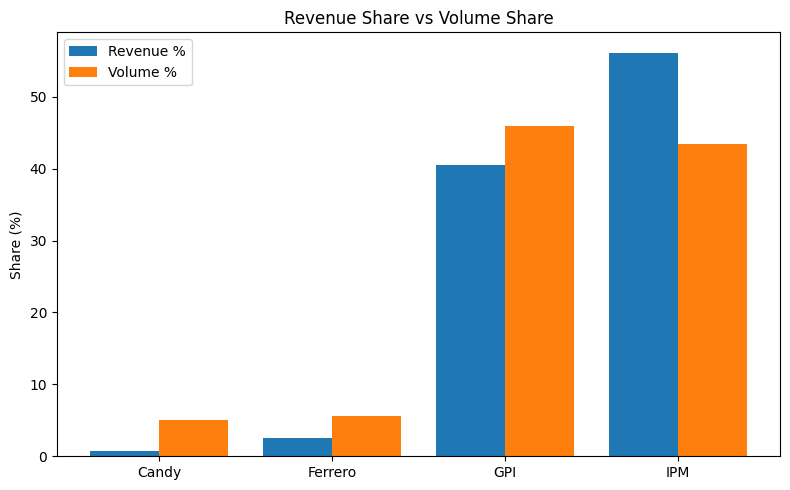

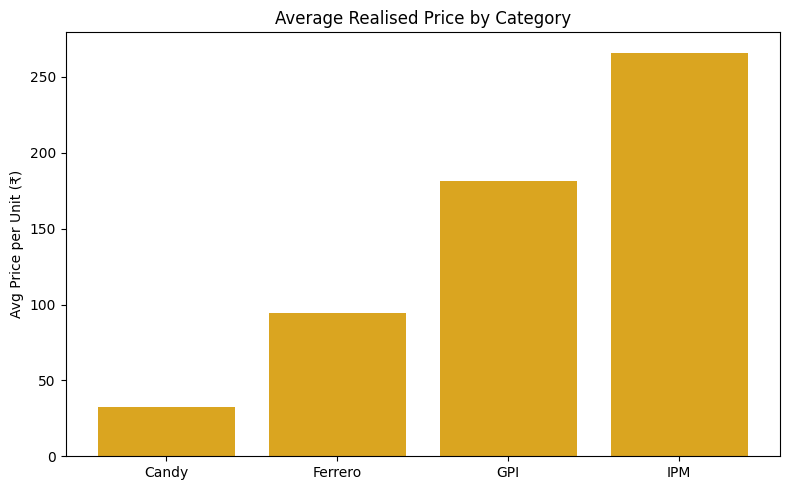

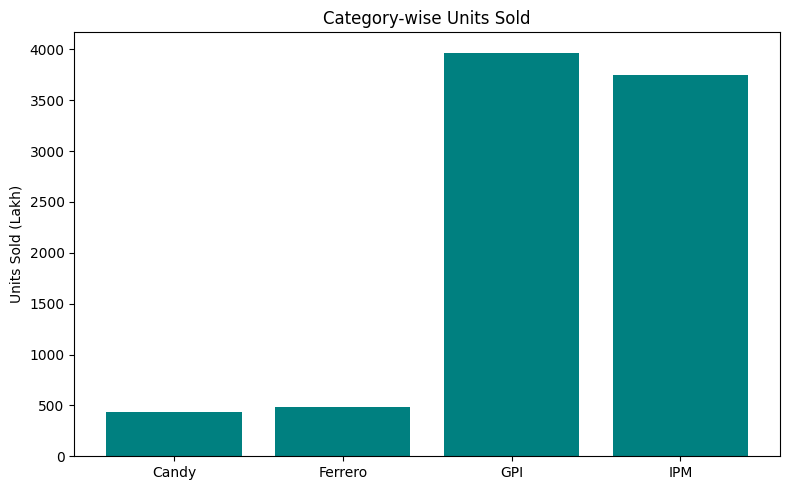

In [4]:
orders = pd.read_csv("orders.csv")
products = pd.read_csv("products.csv")

orders = orders.merge(products[['sku_id','category_name']], on='sku_id')
orders['revenue'] = orders['qty_delivered'] * orders['unit_price']

cat = orders.groupby('category_name').agg(
    revenue=('revenue','sum'),
    units=('qty_delivered','sum')
)

cat['revenue_pct'] = cat['revenue'] / cat['revenue'].sum() * 100
cat['volume_pct'] = cat['units'] / cat['units'].sum() * 100
cat['avg_price'] = cat['revenue'] / cat['units']

plt.figure(figsize=(8,5))
plt.bar(cat.index, cat['revenue']/1e7, color='maroon')
plt.ylabel("Revenue (₹ Cr)")
plt.title("Category-wise Revenue")
plt.tight_layout()
plt.show()

x = range(len(cat))
plt.figure(figsize=(8,5))
plt.bar(x, cat['revenue_pct'], width=0.4, label='Revenue %', align='center')
plt.bar([i+0.4 for i in x], cat['volume_pct'], width=0.4, label='Volume %', align='center')
plt.xticks([i+0.2 for i in x], cat.index)
plt.ylabel("Share (%)")
plt.title("Revenue Share vs Volume Share")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.bar(cat.index, cat['avg_price'], color='goldenrod')
plt.ylabel("Avg Price per Unit (₹)")
plt.title("Average Realised Price by Category")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.bar(cat.index, cat['units']/1e5, color='teal')
plt.ylabel("Units Sold (Lakh)")
plt.title("Category-wise Units Sold")
plt.tight_layout()
plt.show()

In [5]:
print(cat[['revenue','units','revenue_pct','volume_pct','avg_price']].round(2))

                    revenue      units  revenue_pct  volume_pct  avg_price
category_name                                                             
Candy          1.408711e+09   43473537         0.79        5.03      32.40
Ferrero        4.583200e+09   48550630         2.58        5.62      94.40
GPI            7.191335e+10  396918371        40.48       45.96     181.18
IPM            9.972793e+10  374731122        56.14       43.39     266.13


                   revenue      units  outlets  revenue_pct  units_pct  \
channel_type                                                             
Dealer        9.579221e+10  465665839    37603        53.93      53.92   
Hawkers       1.662416e+10   80820015     9432         9.36       9.36   
Modern Trade  5.203346e+09   25339573     2312         2.93       2.93   
Retail        6.001348e+10  291848233   757180        33.79      33.79   

              outlet_pct  revenue_per_outlet  units_per_outlet  
channel_type                                                    
Dealer              4.66          2547461.84          12383.74  
Hawkers             1.17          1762527.05           8568.70  
Modern Trade        0.29          2250582.22          10960.02  
Retail             93.88            79259.19            385.44  


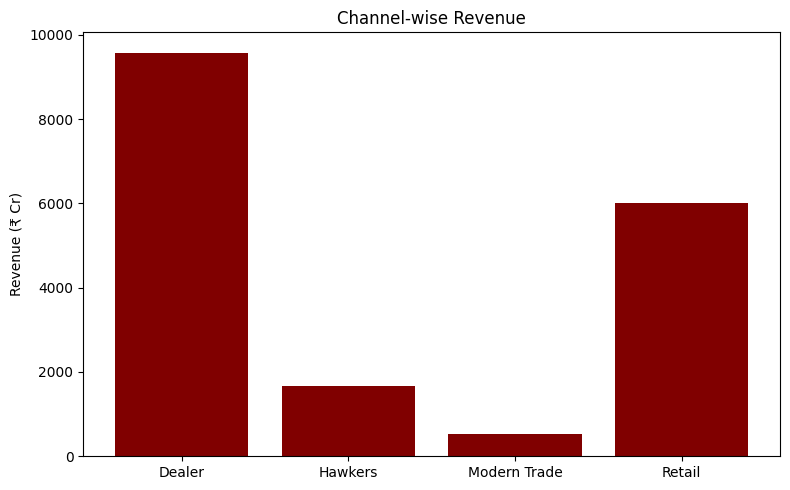

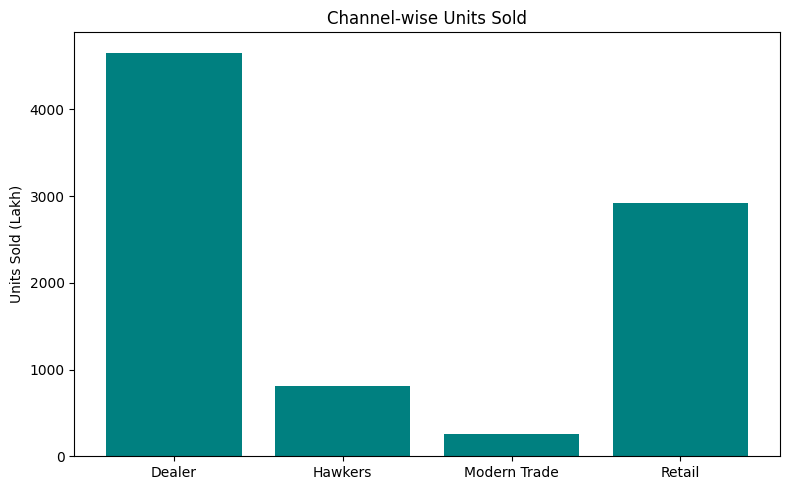

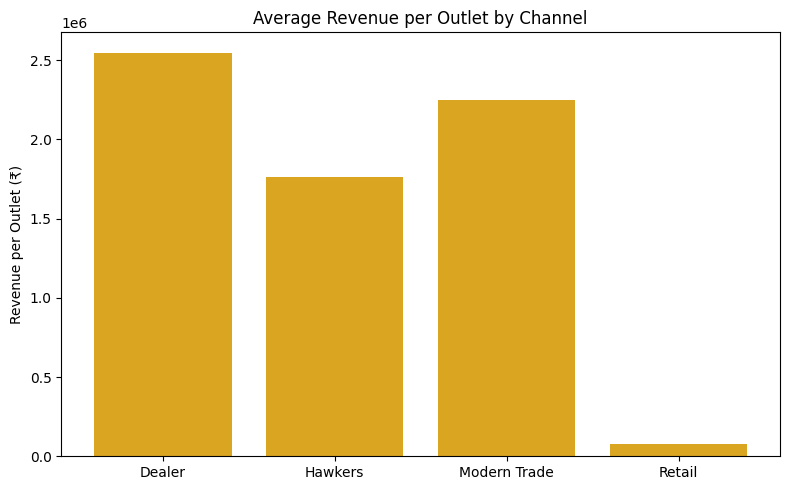

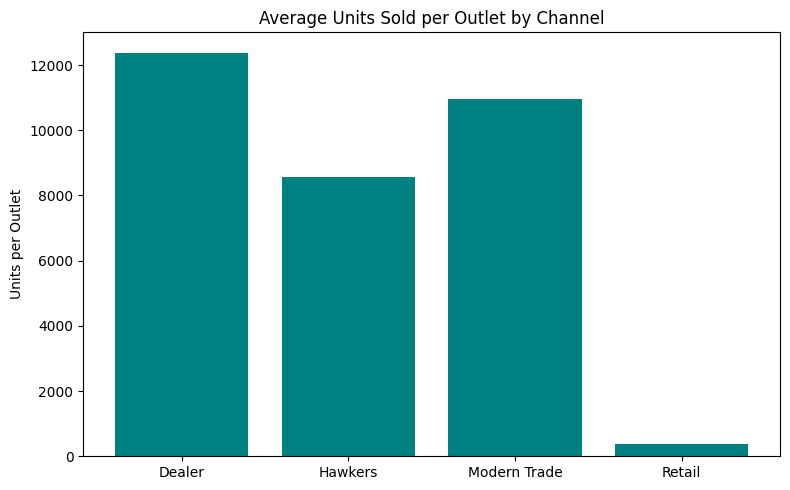

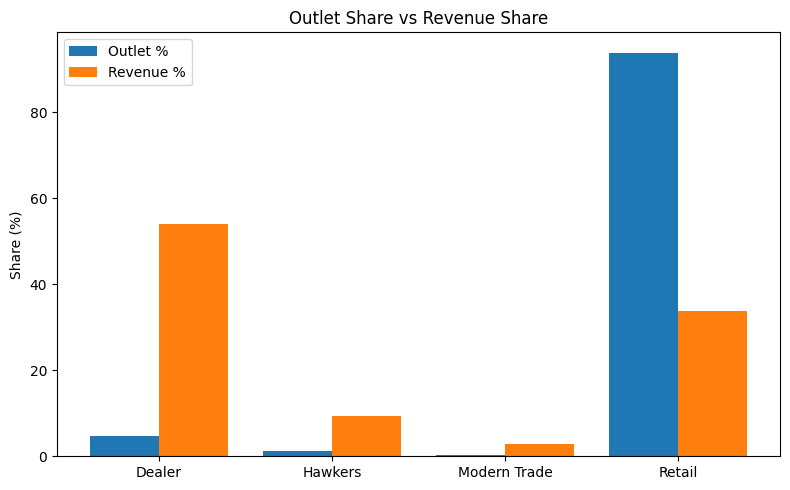

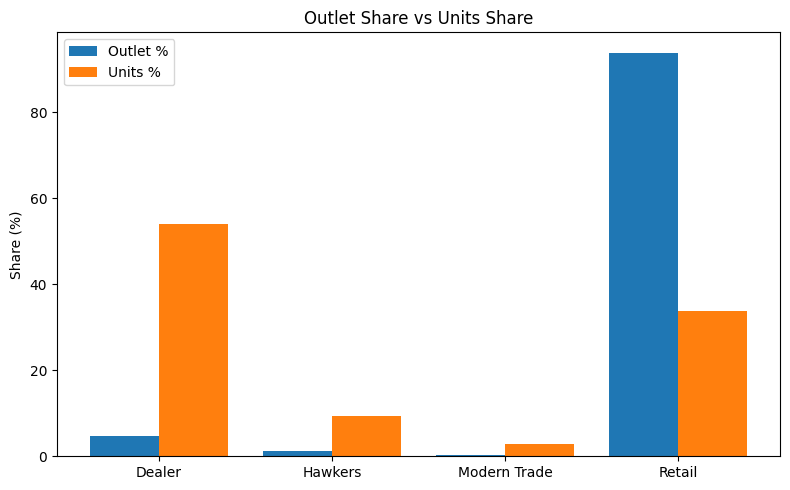

In [6]:
orders = pd.read_csv("orders.csv")
outlets = pd.read_csv("outlets.csv")

orders = orders.merge(outlets[['outlet_id','channel_type']], on='outlet_id')
orders['revenue'] = orders['qty_delivered'] * orders['unit_price']

outlet_counts = outlets.groupby('channel_type')['outlet_id'].nunique()

ch = orders.groupby('channel_type').agg(
    revenue=('revenue','sum'),
    units=('qty_delivered','sum')
)
ch['outlets'] = outlet_counts
ch['revenue_pct'] = ch['revenue'] / ch['revenue'].sum() * 100
ch['units_pct'] = ch['units'] / ch['units'].sum() * 100
ch['outlet_pct'] = ch['outlets'] / ch['outlets'].sum() * 100
ch['revenue_per_outlet'] = ch['revenue'] / ch['outlets']
ch['units_per_outlet'] = ch['units'] / ch['outlets']

print(ch.round(2))

plt.figure(figsize=(8,5))
plt.bar(ch.index, ch['revenue']/1e7, color='maroon')
plt.ylabel("Revenue (₹ Cr)")
plt.title("Channel-wise Revenue")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.bar(ch.index, ch['units']/1e5, color='teal')
plt.ylabel("Units Sold (Lakh)")
plt.title("Channel-wise Units Sold")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.bar(ch.index, ch['revenue_per_outlet'], color='goldenrod')
plt.ylabel("Revenue per Outlet (₹)")
plt.title("Average Revenue per Outlet by Channel")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.bar(ch.index, ch['units_per_outlet'], color='teal')
plt.ylabel("Units per Outlet")
plt.title("Average Units Sold per Outlet by Channel")
plt.tight_layout()
plt.show()

x = range(len(ch))
plt.figure(figsize=(8,5))
plt.bar(x, ch['outlet_pct'], width=0.4, label='Outlet %')
plt.bar([i+0.4 for i in x], ch['revenue_pct'], width=0.4, label='Revenue %')
plt.xticks([i+0.2 for i in x], ch.index)
plt.ylabel("Share (%)")
plt.title("Outlet Share vs Revenue Share")
plt.legend()
plt.tight_layout()
plt.show()

x = range(len(ch))
plt.figure(figsize=(8,5))
plt.bar(x, ch['outlet_pct'], width=0.4, label='Outlet %')
plt.bar([i+0.4 for i in x], ch['units_pct'], width=0.4, label='Units %')
plt.xticks([i+0.2 for i in x], ch.index)
plt.ylabel("Share (%)")
plt.title("Outlet Share vs Units Share")
plt.legend()
plt.tight_layout()
plt.show()

                  revenue      units  outlets  revenue_pct  outlet_pct  \
outlet_tier                                                              
Bronze       1.840695e+10   89584636   362387        10.36       44.93   
Gold         1.153623e+11  560928227   161552        64.94       20.03   
Silver       4.386392e+10  213160797   282588        24.69       35.04   

             revenue_per_outlet  
outlet_tier                      
Bronze                 50793.62  
Gold                  714087.82  
Silver                155222.16  


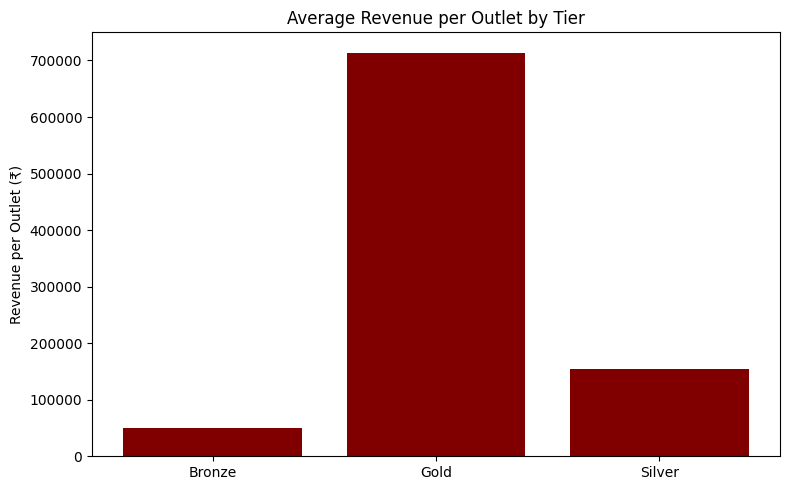

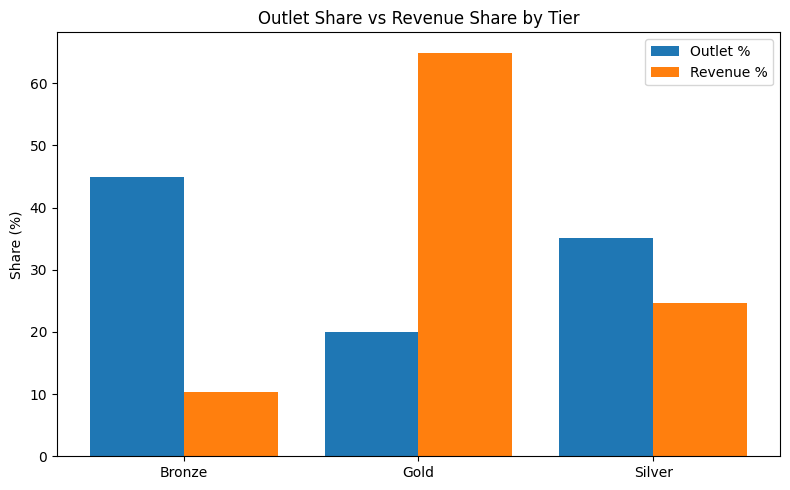

In [7]:
orders = pd.read_csv("orders.csv")
outlets = pd.read_csv("outlets.csv")

orders = orders.merge(outlets[['outlet_id','outlet_tier']], on='outlet_id')
orders['revenue'] = orders['qty_delivered'] * orders['unit_price']

outlet_counts = outlets.groupby('outlet_tier')['outlet_id'].nunique()

tier = orders.groupby('outlet_tier').agg(
    revenue=('revenue','sum'),
    units=('qty_delivered','sum')
)
tier['outlets'] = outlet_counts
tier['revenue_pct'] = tier['revenue'] / tier['revenue'].sum() * 100
tier['outlet_pct'] = tier['outlets'] / tier['outlets'].sum() * 100
tier['revenue_per_outlet'] = tier['revenue'] / tier['outlets']

print(tier.round(2))

plt.figure(figsize=(8,5))
plt.bar(tier.index, tier['revenue_per_outlet'], color='maroon')
plt.ylabel("Revenue per Outlet (₹)")
plt.title("Average Revenue per Outlet by Tier")
plt.tight_layout()
plt.show()

x = range(len(tier))
plt.figure(figsize=(8,5))
plt.bar(x, tier['outlet_pct'], width=0.4, label='Outlet %')
plt.bar([i+0.4 for i in x], tier['revenue_pct'], width=0.4, label='Revenue %')
plt.xticks([i+0.2 for i in x], tier.index)
plt.ylabel("Share (%)")
plt.title("Outlet Share vs Revenue Share by Tier")
plt.legend()
plt.tight_layout()
plt.show()

Top 10 SKUs
                  sku_name category_name      units       revenue
40         Marlboro Pack 1           IPM  240295375  6.543483e+10
0   GPI_Franchise_1 Pack 1           GPI   75810591  2.269769e+10
20  GPI_Franchise_4 Pack 1           GPI   75485219  1.319180e+10
41         Marlboro Pack 2           IPM   33613216  1.310815e+10
44         Marlboro Pack 5           IPM   33551762  9.629356e+09
7   GPI_Franchise_2 Pack 1           GPI   75365369  9.306869e+09
42         Marlboro Pack 3           IPM   33684640  7.332809e+09
15  GPI_Franchise_3 Pack 1           GPI   75512451  6.673035e+09
43         Marlboro Pack 4           IPM   33586129  4.222784e+09
47           TicTac Pack 3       Ferrero    6952121  8.939037e+08
Bottom 10 SKUs
                    sku_name category_name    units       revenue
27    GPI_Franchise_5 Pack 1           GPI  2618846  2.799023e+08
32    GPI_Franchise_5 Pack 6           GPI  2646752  2.785971e+08
58  Candy_Franchise_2 Pack 4         Candy  61642

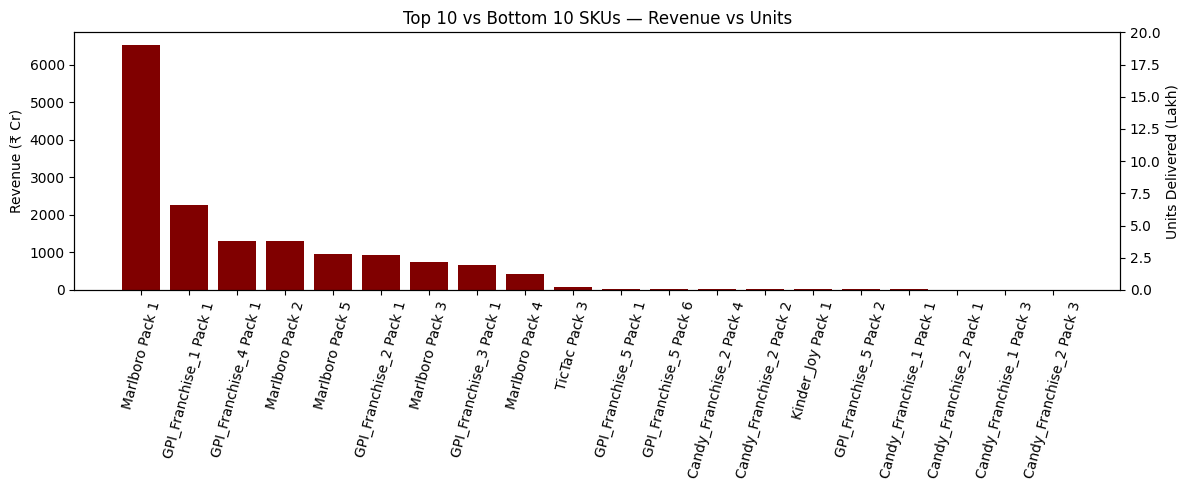

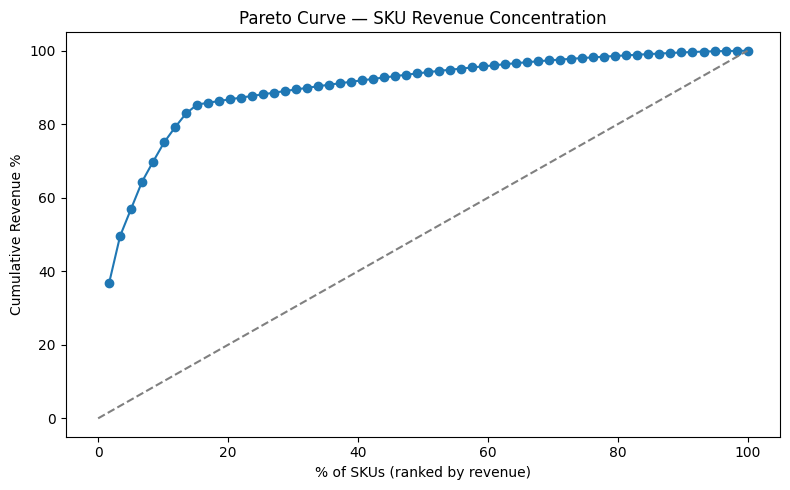

In [8]:
orders = pd.read_csv("orders.csv")
products = pd.read_csv("products.csv")

orders = orders.merge(products[['sku_id','sku_name','category_name']], on='sku_id')
orders['revenue'] = orders['qty_delivered'] * orders['unit_price']

sku = orders.groupby(['sku_id','sku_name','category_name']).agg(
    revenue=('revenue','sum'),
    units=('qty_delivered','sum')
).reset_index()

sku = sku.sort_values('revenue', ascending=False)

print("Top 10 SKUs")
print(sku.head(10)[['sku_name','category_name','units','revenue']].round(2))

print("Bottom 10 SKUs")
print(sku.tail(10)[['sku_name','category_name','units','revenue']].round(2))

print("Units Variation:", (sku['units'].std() / sku['units'].mean()).round(3))
print("Revenue Variation:", (sku['revenue'].std() / sku['revenue'].mean()).round(3))

top10 = sku.head(10)
bottom10 = sku.tail(10)
combo = pd.concat([top10, bottom10])
combo['units_lakh'] = combo['units'] / 1e5

fig, ax1 = plt.subplots(figsize=(12,5))
ax1.bar(combo['sku_name'], combo['revenue']/1e7, color='maroon')
ax1.set_ylabel("Revenue (₹ Cr)")
plt.xticks(rotation=75)

ax2 = ax1.twinx()
ax2.plot(combo['sku_name'], combo['units_lakh'], color='goldenrod', marker='o')
ax2.set_ylabel("Units Delivered (Lakh)")
ax2.set_ylim(0, 20)
plt.title("Top 10 vs Bottom 10 SKUs — Revenue vs Units")
plt.tight_layout()
plt.show()

sku_sorted = sku.sort_values('revenue', ascending=False).reset_index(drop=True)
sku_sorted['cum_revenue_pct'] = sku_sorted['revenue'].cumsum() / sku_sorted['revenue'].sum() * 100
sku_sorted['sku_rank_pct'] = (sku_sorted.index+1) / len(sku_sorted) * 100

plt.figure(figsize=(8,5))
plt.plot(sku_sorted['sku_rank_pct'], sku_sorted['cum_revenue_pct'], marker='o')
plt.plot([0,100],[0,100], linestyle='--', color='gray')
plt.xlabel("% of SKUs (ranked by revenue)")
plt.ylabel("Cumulative Revenue %")
plt.title("Pareto Curve — SKU Revenue Concentration")
plt.tight_layout()
plt.show()

                        revenue  qty_ordered  qty_delivered  fulfilment_pct
state_name                                                                 
Uttar Pradesh      9.942996e+09     52649814       49119268           93.29
Maharashtra        8.889536e+09     47011159       43457733           92.44
Madhya Pradesh     8.345977e+09     44447534       41310251           92.94
Gujarat            7.869240e+09     41726343       38640731           92.61
Odisha             7.850856e+09     41438131       38527042           92.97
West Bengal        7.785236e+09     40982035       38197987           93.21
Chhattisgarh       7.654721e+09     40247454       37431977           93.00
Andhra Pradesh     7.493011e+09     39710443       36713760           92.45
Kerala             7.389538e+09     38243652       35689395           93.32
Jharkhand          7.220404e+09     38384715       35451480           92.36
Telangana          7.092471e+09     36939384       34296101           92.84
Bihar       

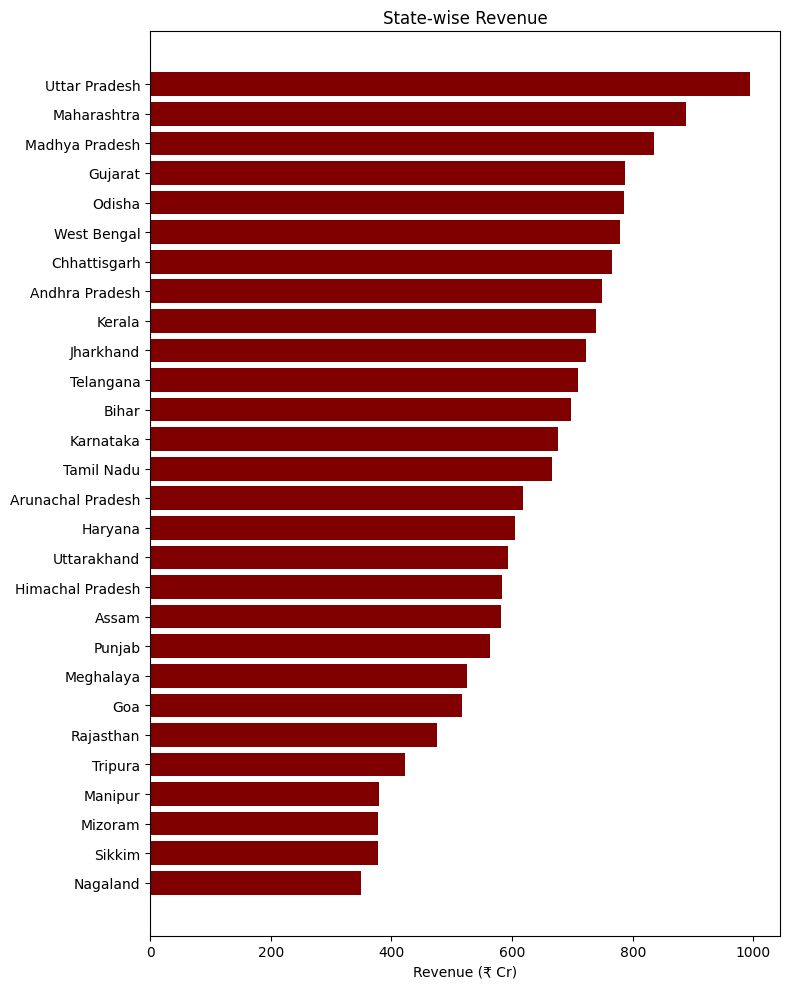

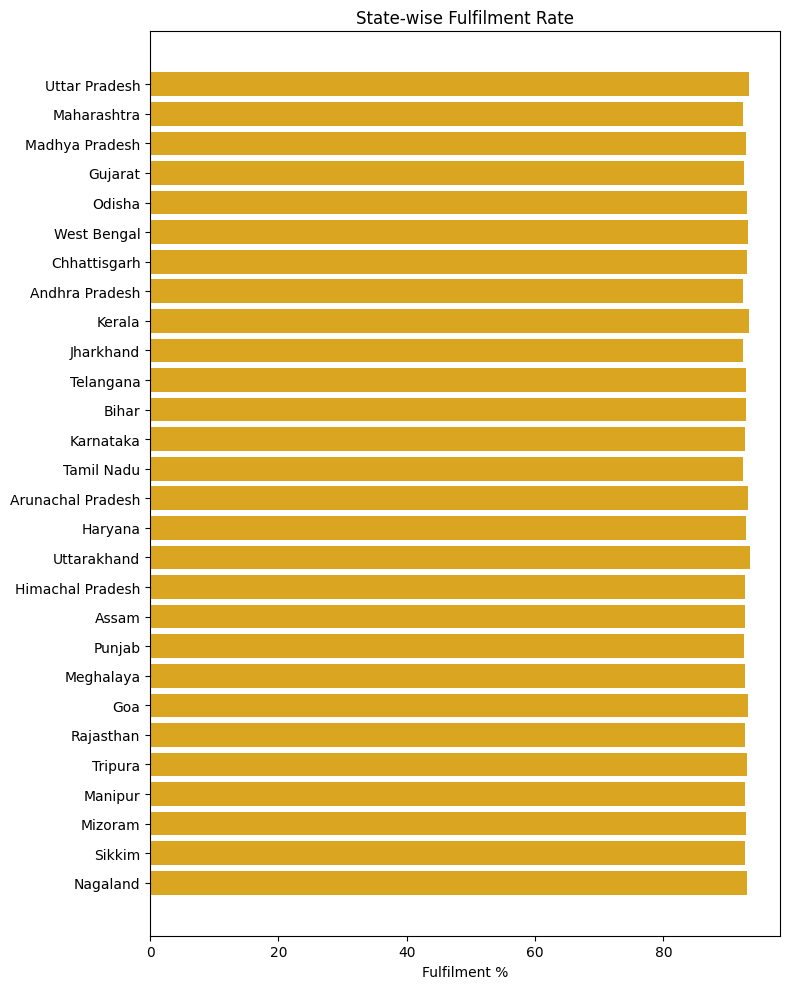

In [9]:
orders = pd.read_csv("orders.csv")
outlets = pd.read_csv("outlets.csv")

orders = orders.merge(outlets[['outlet_id','state_name']], on='outlet_id')
orders['revenue'] = orders['qty_delivered'] * orders['unit_price']

state = orders.groupby('state_name').agg(
    revenue=('revenue','sum'),
    qty_ordered=('qty_ordered','sum'),
    qty_delivered=('qty_delivered','sum')
)
state['fulfilment_pct'] = state['qty_delivered'] / state['qty_ordered'] * 100
state = state.sort_values('revenue', ascending=False)

print(state.round(2))

print("Best/Worst ratio:", (state['revenue'].max() / state['revenue'].min()).round(2))
print("Revenue CV:", (state['revenue'].std() / state['revenue'].mean()).round(3))
print("Fulfilment CV:", (state['fulfilment_pct'].std() / state['fulfilment_pct'].mean()).round(3))

plt.figure(figsize=(8,10))
plt.barh(state.index[::-1], state['revenue'].values[::-1]/1e7, color='maroon')
plt.xlabel("Revenue (₹ Cr)")
plt.title("State-wise Revenue")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,10))
plt.barh(state.index[::-1], state['fulfilment_pct'].values[::-1], color='goldenrod')
plt.xlabel("Fulfilment %")
plt.title("State-wise Fulfilment Rate")
plt.tight_layout()
plt.show()

            productivity  service_level  inventory_turns  inventory_days
month                                                                   
2024-08-01         0.628          0.925            1.536          19.533
2024-09-01         0.628          0.927            1.992          15.071
2024-10-01         0.767          0.926            2.391          12.550
2024-11-01         0.790          0.931            2.549          11.777
2024-12-01         0.685          0.929            2.604          11.524
2025-01-01         0.690          0.936            2.639          11.373
2025-02-01         0.629          0.929            2.654          11.309
2025-03-01         0.628          0.931            2.649          11.332
2025-04-01         0.628          0.929            2.651          11.324
2025-05-01         0.628          0.925            2.651          11.321
2025-06-01         0.629          0.930            2.638          11.377
2025-07-01         0.628          0.927            

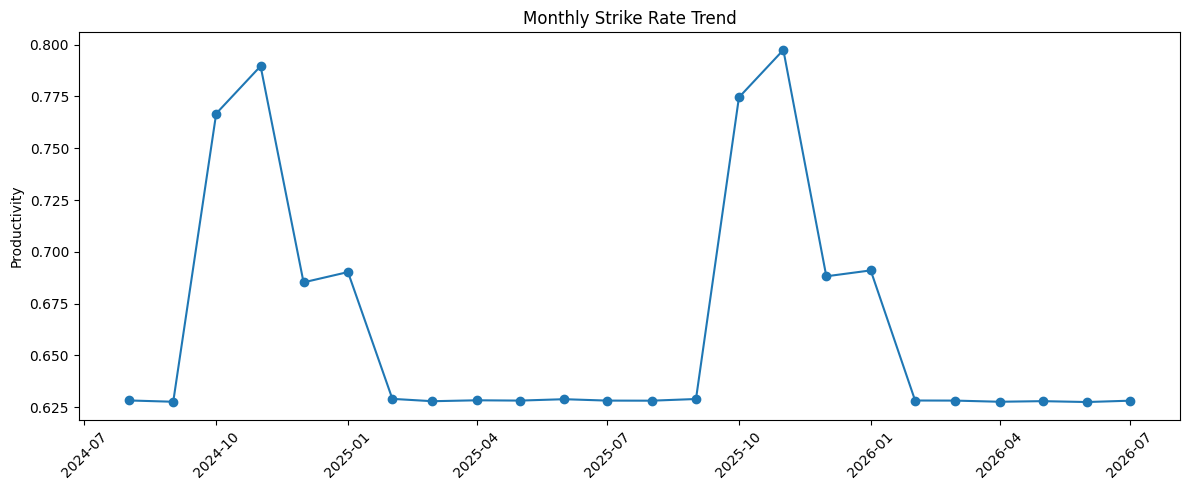

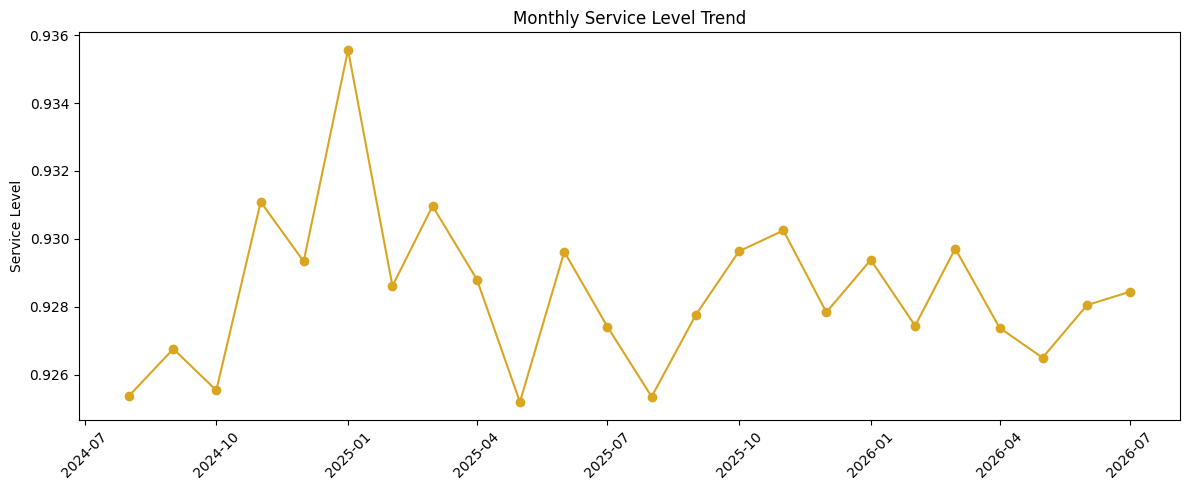

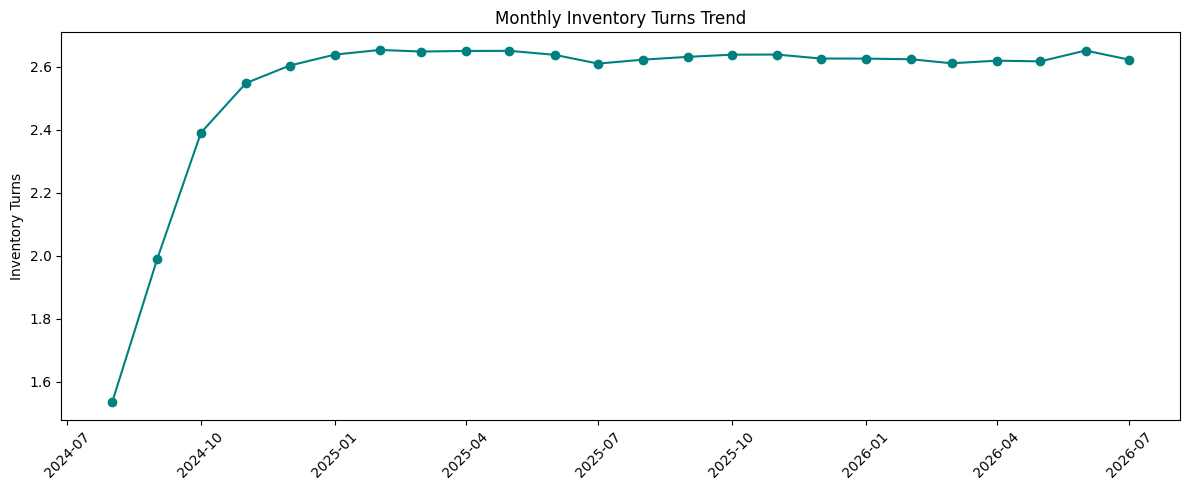

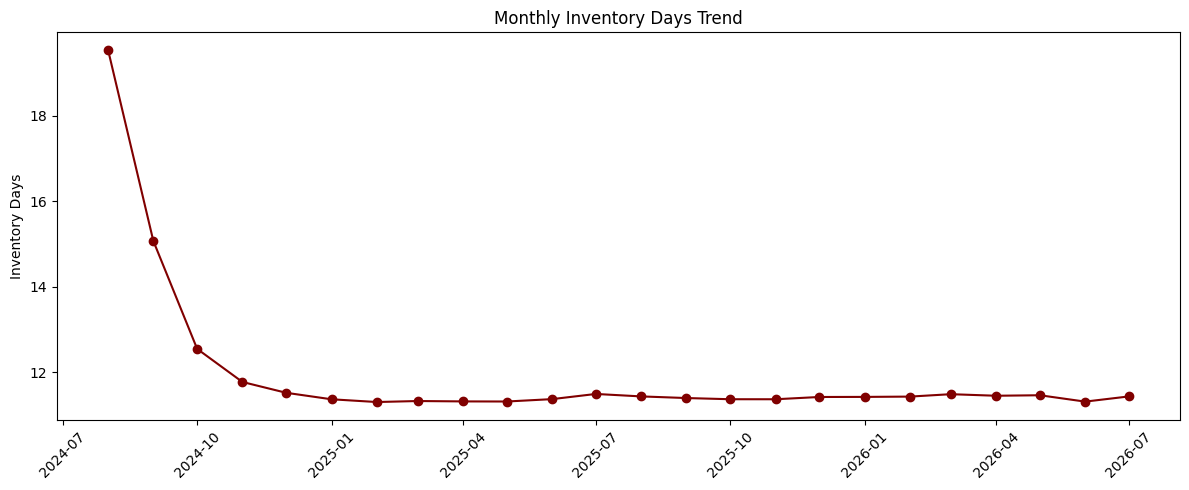

In [11]:
kpi = pd.read_csv("kpi_state_month.csv")
kpi['month'] = pd.to_datetime(kpi['month'])

monthly = kpi.groupby('month').agg(
    productivity=('productivity','mean'),
    service_level=('service_level','mean'),
    inventory_turns=('inventory_turns','mean'),
    inventory_days=('inventory_days','mean')
).sort_index()

print(monthly.round(3))

plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly['productivity'], marker='o')
plt.xticks(rotation=45)
plt.ylabel("Productivity")
plt.title("Monthly Strike Rate Trend")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly['service_level'], marker='o', color='goldenrod')
plt.xticks(rotation=45)
plt.ylabel("Service Level")
plt.title("Monthly Service Level Trend")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly['inventory_turns'], marker='o', color='teal')
plt.xticks(rotation=45)
plt.ylabel("Inventory Turns")
plt.title("Monthly Inventory Turns Trend")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly['inventory_days'], marker='o', color='maroon')
plt.xticks(rotation=45)
plt.ylabel("Inventory Days")
plt.title("Monthly Inventory Days Trend")
plt.tight_layout()
plt.show()

productivity vs dropsize correlation: 0.605
OOS% vs Service Level correlation: -0.428


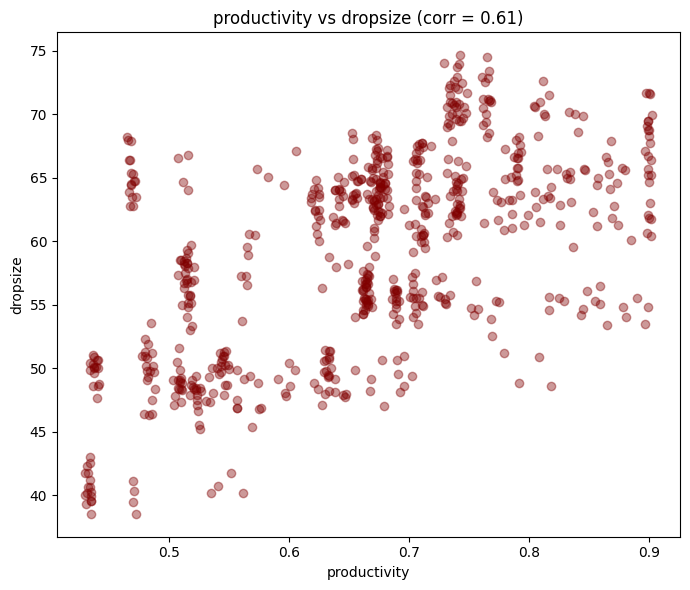

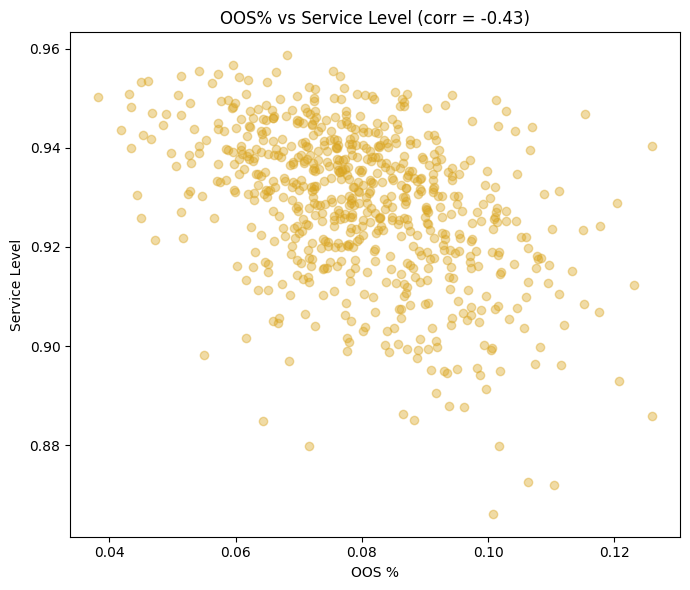

In [14]:
kpi_state = pd.read_csv("kpi_state_month.csv")
kpi_cat = pd.read_csv("kpi_state_month_category.csv")

kpi_cat_avg = kpi_cat.groupby(['state_name','month'])['oos_pct'].mean().reset_index()

merged = kpi_state.merge(kpi_cat_avg, on=['state_name','month'])

corr1 = merged['productivity'].corr(merged['dropsize'])
corr2 = merged['oos_pct'].corr(merged['service_level'])

print("productivity vs dropsize correlation:", round(corr1,3))
print("OOS% vs Service Level correlation:", round(corr2,3))

plt.figure(figsize=(7,6))
plt.scatter(merged['productivity'], merged['dropsize'], alpha=0.4, color='maroon')
plt.xlabel("productivity")
plt.ylabel("dropsize")
plt.title(f"productivity vs dropsize (corr = {round(corr1,2)})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,6))
plt.scatter(merged['oos_pct'], merged['service_level'], alpha=0.4, color='goldenrod')
plt.xlabel("OOS %")
plt.ylabel("Service Level")
plt.title(f"OOS% vs Service Level (corr = {round(corr2,2)})")
plt.tight_layout()
plt.show()

In [15]:
outlets = pd.read_csv("outlets.csv")
orders = pd.read_csv("orders.csv")
visits = pd.read_csv("visits.csv")

outlets['closure_date'] = pd.to_datetime(outlets['closure_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])
visits['visit_date'] = pd.to_datetime(visits['visit_date'])

inactive_outlets = outlets[outlets['is_active'] == False][['outlet_id','closure_date']]

orders_check = orders.merge(inactive_outlets, on='outlet_id')
visits_check = visits.merge(inactive_outlets, on='outlet_id')

orders_after_closure = orders_check[orders_check['order_date'] >= orders_check['closure_date']]
visits_after_closure = visits_check[visits_check['visit_date'] >= visits_check['closure_date']]

print("Total inactive outlets:", len(inactive_outlets))
print("Orders after closure_date:", len(orders_after_closure))
print("Visits after closure_date:", len(visits_after_closure))
print("Inactive outlets with orders after closure:", orders_after_closure['outlet_id'].nunique())
print("Inactive outlets with visits after closure:", visits_after_closure['outlet_id'].nunique())

Total inactive outlets: 77735
Orders after closure_date: 0
Visits after closure_date: 0
Inactive outlets with orders after closure: 0
Inactive outlets with visits after closure: 0


In [ ]:
orders_after_closure[
    ['outlet_id', 'closure_date', 'order_date']
].sort_values('closure_date').head(20)

,outlet_id,closure_date,order_date
522471,OUT145172,2024-08-01,2024-08-01
779059,OUT216178,2024-08-01,2024-08-01
522469,OUT145172,2024-08-01,2024-08-01
522472,OUT145172,2024-08-01,2024-08-01
779064,OUT216178,2024-08-01,2024-08-01
10032,OUT002792,2024-08-01,2024-08-01
1629695,OUT429794,2024-08-01,2024-08-01
779060,OUT216178,2024-08-01,2024-08-01
10031,OUT002792,2024-08-01,2024-08-01
779063,OUT216178,2024-08-01,2024-08-01


In [ ]:
visits_after_closure[
    ['outlet_id', 'closure_date', 'visit_date']
].sort_values('closure_date').head(20)

,outlet_id,closure_date,visit_date
3928,OUT002792,2024-08-01,2024-08-01
674877,OUT429794,2024-08-01,2024-08-01
225687,OUT145172,2024-08-01,2024-08-01
1029592,OUT656078,2024-08-01,2024-08-01
336456,OUT216178,2024-08-01,2024-08-01
570698,OUT363716,2024-08-01,2024-08-01
1083161,OUT690016,2024-08-02,2024-08-02
1189004,OUT758228,2024-08-02,2024-08-02
195970,OUT125867,2024-08-02,2024-08-02
43590,OUT027994,2024-08-02,2024-08-02


In [ ]:
orders_after = orders_check[
    orders_check['order_date'] > orders_check['closure_date']
]

visits_after = visits_check[
    visits_check['visit_date'] > visits_check['closure_date']
]

print(len(orders_after))
print(len(visits_after))

0
0


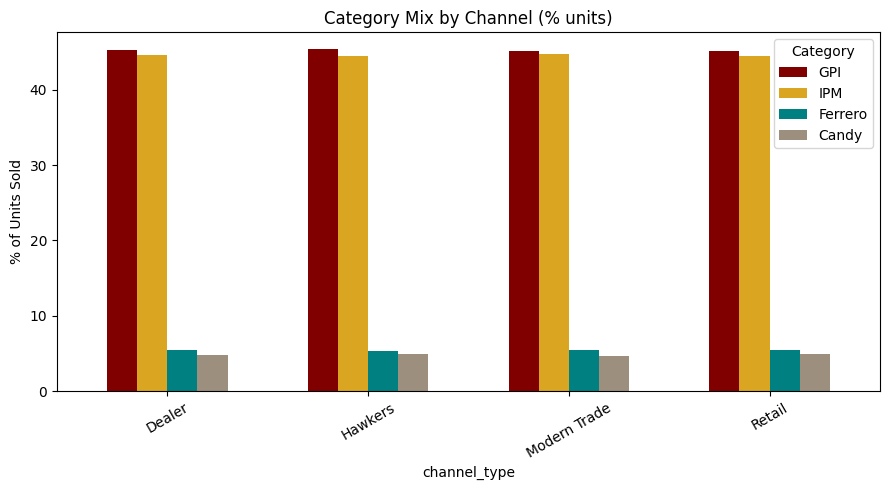

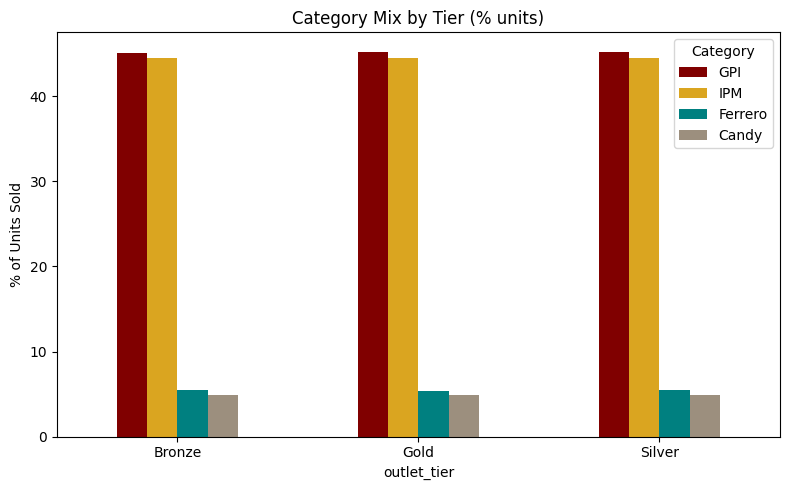

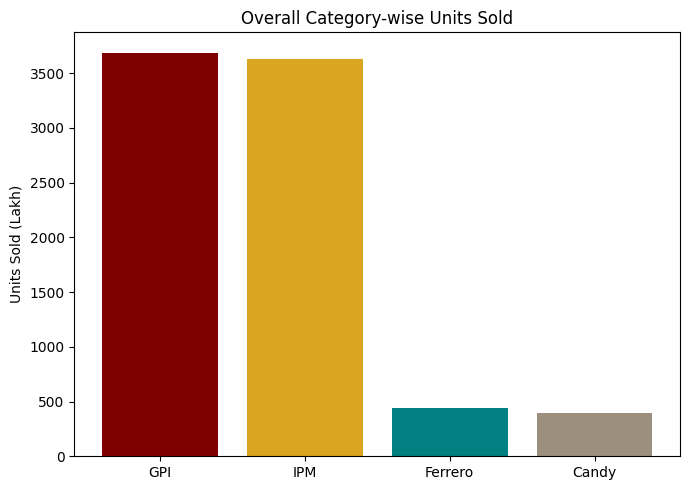

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv("orders.csv")
outlets = pd.read_csv("outlets.csv")
products = pd.read_csv("products.csv")
visits = pd.read_csv("visits.csv")

orders = orders.merge(products[['sku_id','category_name']], on='sku_id')
orders = orders.merge(outlets[['outlet_id','channel_type','outlet_tier']], on='outlet_id')

successful_visits = visits[visits['visit_outcome'] == 'Order Placed']['visit_id']
orders_success = orders[orders['visit_id'].isin(successful_visits)]

cats = ['GPI','IPM','Ferrero','Candy']

channel_cat = orders_success.groupby(['channel_type','category_name'])['qty_delivered'].sum().unstack(fill_value=0)
channel_cat = channel_cat[[c for c in cats if c in channel_cat.columns]]
channel_cat_pct = channel_cat.div(channel_cat.sum(axis=1), axis=0) * 100

tier_cat = orders_success.groupby(['outlet_tier','category_name'])['qty_delivered'].sum().unstack(fill_value=0)
tier_cat = tier_cat[[c for c in cats if c in tier_cat.columns]]
tier_cat_pct = tier_cat.div(tier_cat.sum(axis=1), axis=0) * 100

colors = ['maroon','goldenrod','teal','#9C8F7E']

channel_cat_pct.plot(kind='bar', figsize=(9,5), color=colors, width=0.6)
plt.ylabel("% of Units Sold")
plt.title("Category Mix by Channel (% units)")
plt.xticks(rotation=30)
plt.legend(title="Category")
plt.tight_layout()
plt.show()

tier_cat_pct.plot(kind='bar', figsize=(8,5), color=colors, width=0.5)
plt.ylabel("% of Units Sold")
plt.title("Category Mix by Tier (% units)")
plt.xticks(rotation=0)
plt.legend(title="Category")
plt.tight_layout()
plt.show()

overall = orders_success.groupby('category_name')['qty_delivered'].sum()
overall = overall[[c for c in cats if c in overall.index]]

plt.figure(figsize=(7,5))
plt.bar(overall.index, overall.values/1e5, color=colors)
plt.ylabel("Units Sold (Lakh)")
plt.title("Overall Category-wise Units Sold")
plt.tight_layout()
plt.show()

In [ ]:
outlet_id = "OUT000001"  

orders = pd.read_csv("orders.csv")
outlets = pd.read_csv("outlets.csv")
products = pd.read_csv("products.csv")
visits = pd.read_csv("visits.csv")

orders = orders.merge(products[['sku_id','category_name','sku_name']], on='sku_id')

successful_visits = visits[visits['visit_outcome'] == 'Order Placed']['visit_id']

outlet_orders = orders[
    (orders['outlet_id'] == outlet_id) &
    (orders['visit_id'].isin(successful_visits))
]

print(f"Outlet: {outlet_id}")
print(f"Total successful visits: {outlet_orders['visit_id'].nunique()}")
print(f"Total order lines: {len(outlet_orders)}")
print()

print("Category-wise units sold:")
cat_split = outlet_orders.groupby('category_name')['qty_delivered'].sum()
print(cat_split)
print()

print("SKU-wise breakdown:")
sku_split = outlet_orders.groupby(['category_name','sku_name'])['qty_delivered'].sum().reset_index()
print(sku_split.sort_values('qty_delivered', ascending=False).to_string(index=False))

Outlet: OUT000001
Total successful visits: 28
Total order lines: 102

Category-wise units sold:
category_name
Candy        8
Ferrero     17
GPI        226
IPM        177
Name: qty_delivered, dtype: int64

SKU-wise breakdown:
category_name                 sku_name  qty_delivered
          IPM          Marlboro Pack 1            104
          GPI   GPI_Franchise_4 Pack 1             57
          GPI   GPI_Franchise_1 Pack 1             48
          GPI   GPI_Franchise_3 Pack 1             41
          GPI   GPI_Franchise_2 Pack 1             26
          IPM          Marlboro Pack 4             25
          IPM          Marlboro Pack 5             18
          IPM          Marlboro Pack 3             15
          IPM          Marlboro Pack 2             15
        Candy Candy_Franchise_1 Pack 3              6
      Ferrero        Kinder_Joy Pack 3              6
          GPI   GPI_Franchise_5 Pack 2              6
          GPI   GPI_Franchise_1 Pack 4              6
          GPI   GPI